In [1]:
# Purpose: 

In [2]:
from datetime import datetime

# Current date and time
st=datetime.now()

In [3]:
print(st)

2025-03-17 15:23:52.096128


In [4]:
### Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from category_encoders import TargetEncoder
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, ReLU
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow.keras.backend as K
import shutil
import keras_tuner as kt
import tensorflow as tf

In [5]:
### Load Data
data = pd.read_csv('dataset_Porter.csv')


In [6]:
### Display first few rows
display(data.head())

,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders
0,1.0,2015-02-06 22:24:17,2015-02-06 23:27:16,df263d996281d984952c07998dc54358,american,1.0,4,3441,4,557,1239,33.0,14.0,21.0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:56:29,f0ade77b43923b38237db569b016ba25,mexican,2.0,1,1900,1,1400,1400,1.0,2.0,2.0
2,3.0,2015-01-22 20:39:28,2015-01-22 21:09:09,f0ade77b43923b38237db569b016ba25,NaN,1.0,1,1900,1,1900,1900,1.0,0.0,0.0
3,3.0,2015-02-03 21:21:45,2015-02-03 22:13:00,f0ade77b43923b38237db569b016ba25,NaN,1.0,6,6900,5,600,1800,1.0,1.0,2.0
4,3.0,2015-02-15 02:40:36,2015-02-15 03:20:26,f0ade77b43923b38237db569b016ba25,NaN,1.0,3,3900,3,1100,1600,6.0,6.0,9.0


In [7]:
### Data structure and basic info
display(data.info())
display(data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197428 entries, 0 to 197427
Data columns (total 14 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   market_id                 196441 non-null  float64
 1   created_at                197428 non-null  object 
 2   actual_delivery_time      197421 non-null  object 
 3   store_id                  197428 non-null  object 
 4   store_primary_category    192668 non-null  object 
 5   order_protocol            196433 non-null  float64
 6   total_items               197428 non-null  int64  
 7   subtotal                  197428 non-null  int64  
 8   num_distinct_items        197428 non-null  int64  
 9   min_item_price            197428 non-null  int64  
 10  max_item_price            197428 non-null  int64  
 11  total_onshift_partners    181166 non-null  float64
 12  total_busy_partners       181166 non-null  float64
 13  total_outstanding_orders  181166 non-null  f

None

,market_id,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders
count,196441.000000,196433.000000,197428.000000,197428.000000,197428.000000,197428.000000,197428.000000,181166.000000,181166.000000,181166.000000
mean,2.978706,2.882352,3.196391,2682.331402,2.670791,686.218470,1159.588630,44.808093,41.739747,58.050065
std,1.524867,1.503771,2.666546,1823.093688,1.630255,522.038648,558.411377,34.526783,32.145733,52.661830
min,1.000000,1.000000,1.000000,0.000000,1.000000,-86.000000,0.000000,-4.000000,-5.000000,-6.000000
25%,2.000000,1.000000,2.000000,1400.000000,1.000000,299.000000,800.000000,17.000000,15.000000,17.000000
50%,3.000000,3.000000,3.000000,2200.000000,2.000000,595.000000,1095.000000,37.000000,34.000000,41.000000
75%,4.000000,4.000000,4.000000,3395.000000,3.000000,949.000000,1395.000000,65.000000,62.000000,85.000000
max,6.000000,7.000000,411.000000,27100.000000,20.000000,14700.000000,14700.000000,171.000000,154.000000,285.000000


In [8]:
### Feature Engineering
data['created_at'] = pd.to_datetime(data['created_at'])
data['actual_delivery_time'] = pd.to_datetime(data['actual_delivery_time'])
data['delivery_time_in_minutes'] = (data['actual_delivery_time'] - data['created_at']).dt.total_seconds() / 60
data['order_hour'] = data['created_at'].dt.hour
data['order_day'] = data['created_at'].dt.dayofweek
data['order_to_partner_ratio'] = data['total_outstanding_orders'] / (data['total_onshift_partners'] + 1)

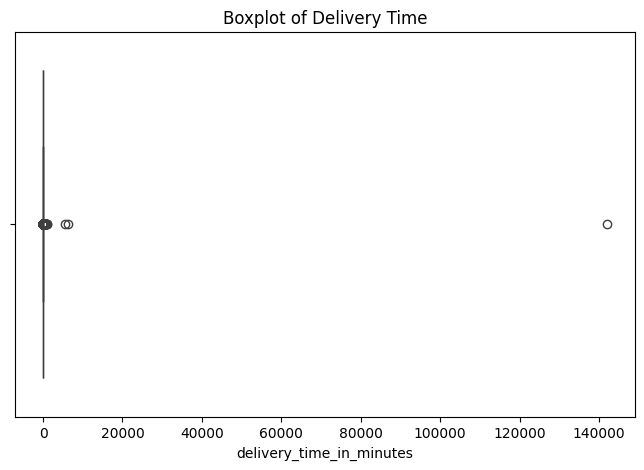

In [9]:
### Checking for outliers
plt.figure(figsize=(8, 5))
sns.boxplot(x=data['delivery_time_in_minutes'])
plt.title('Boxplot of Delivery Time')
plt.show()


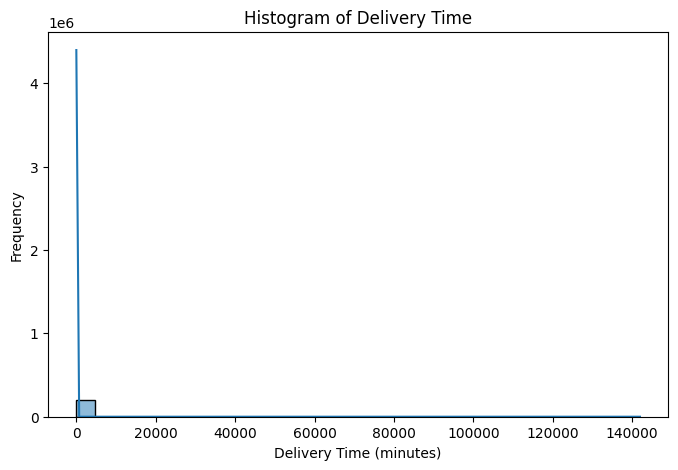

In [10]:
### Histogram of Delivery Time Distribution
plt.figure(figsize=(8, 5))
sns.histplot(data['delivery_time_in_minutes'], bins=30, kde=True)
plt.title('Histogram of Delivery Time')
plt.xlabel('Delivery Time (minutes)')
plt.ylabel('Frequency')
plt.show()

In [11]:
### Outlier handling using IQR and capping at upper bound
Q1 = data['delivery_time_in_minutes'].quantile(0.25)
Q3 = data['delivery_time_in_minutes'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
data['delivery_time_in_minutes'] = np.where(data['delivery_time_in_minutes'] > upper_bound, np.ceil(upper_bound), data['delivery_time_in_minutes'])

data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.dropna(inplace=True)
data.drop(columns=['store_id', 'created_at', 'actual_delivery_time'], inplace=True, errors='ignore')
data = data.dropna(subset=['delivery_time_in_minutes'])


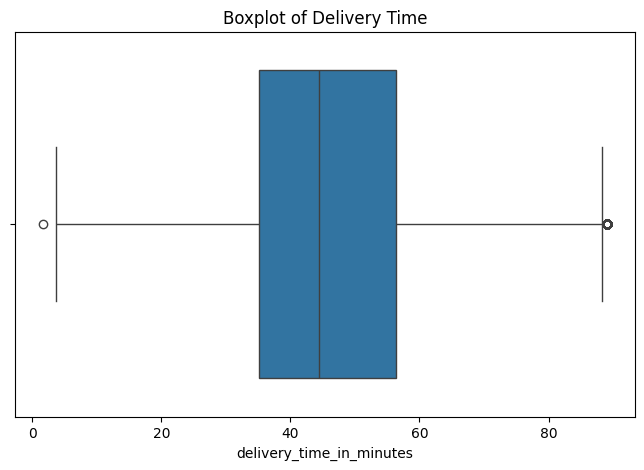

In [12]:
### Checking for outliers
plt.figure(figsize=(8, 5))
sns.boxplot(x=data['delivery_time_in_minutes'])
plt.title('Boxplot of Delivery Time')
plt.show()

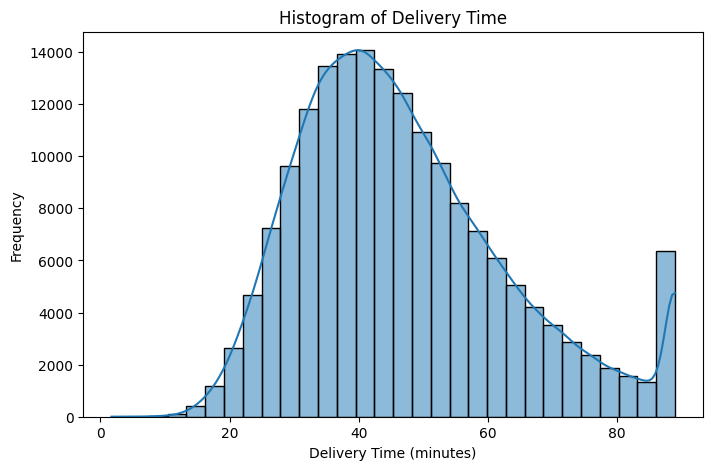

In [13]:
### Histogram of Delivery Time Distribution
plt.figure(figsize=(8, 5))
sns.histplot(data['delivery_time_in_minutes'], bins=30, kde=True)
plt.title('Histogram of Delivery Time')
plt.xlabel('Delivery Time (minutes)')
plt.ylabel('Frequency')
plt.show()

In [14]:
data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.dropna(inplace=True)
data.drop(columns=['store_id', 'created_at', 'actual_delivery_time'], inplace=True, errors='ignore')
data = data.dropna(subset=['delivery_time_in_minutes'])

In [15]:
data.isna().sum()

market_id                   0
store_primary_category      0
order_protocol              0
total_items                 0
subtotal                    0
num_distinct_items          0
min_item_price              0
max_item_price              0
total_onshift_partners      0
total_busy_partners         0
total_outstanding_orders    0
delivery_time_in_minutes    0
order_hour                  0
order_day                   0
order_to_partner_ratio      0
dtype: int64

In [16]:
### Encoding categorical columns using Target Encoding
encoder = TargetEncoder()
for col in ['store_primary_category', 'market_id', 'order_protocol']:
    data[col] = encoder.fit_transform(data[col], data['delivery_time_in_minutes'])

X_numeric = data.drop(columns=['delivery_time_in_minutes']).select_dtypes(include=[np.number])
poly = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)
X_poly = poly.fit_transform(X_numeric)
X_poly = pd.DataFrame(X_poly, columns=poly.get_feature_names_out(X_numeric.columns))

X_train, X_test, y_train, y_test = train_test_split(X_poly, data['delivery_time_in_minutes'], test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.astype(float))
X_test = scaler.transform(X_test.astype(float))

In [17]:
# ### Export processed data to Excel
# poly.to_excel("processed_porter_data_poly_00.xlsx", index=False)

In [18]:
### Define R² Metric
@tf.function
def r2_keras(y_true, y_pred):
    SS_res = K.sum(K.square(y_true - y_pred))
    SS_tot = K.sum(K.square(y_true - K.mean(y_true)))
    return (1 - SS_res / (SS_tot + K.epsilon()))

In [19]:
### Define Hyperparameter Tuning Function
def build_tuned_model(hp):
    model = Sequential()
    model.add(Dense(hp.Int('units_1', min_value=64, max_value=512, step=64),
                    kernel_regularizer=l2(hp.Float('l2_lambda', min_value=1e-5, max_value=1e-2, sampling='LOG')),
                    input_shape=(X_train.shape[1],)))
    model.add(ReLU())
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float('dropout_1', min_value=0.1, max_value=0.5, step=0.1)))
    
    for i in range(hp.Int('num_layers', 1, 4)):
        model.add(Dense(hp.Int(f'units_{i+2}', min_value=32, max_value=256, step=32),
                        kernel_regularizer=l2(hp.Float(f'l2_lambda_{i+2}', min_value=1e-5, max_value=1e-2, sampling='LOG'))))
        model.add(ReLU())
        model.add(BatchNormalization())
        model.add(Dropout(hp.Float(f'dropout_{i+2}', min_value=0.1, max_value=0.5, step=0.1)))
    
    model.add(Dense(1))
    model.compile(optimizer=hp.Choice('optimizer', ['adam', 'rmsprop', 'sgd']),
                  loss='mse',
                  metrics=['mae', 'mse', 'mape', tf.keras.metrics.MeanMetricWrapper(r2_keras, name='r2')])
    return model


In [20]:
### Hyperparameter Tuning Setup
shutil.rmtree('keras_tuner_logs', ignore_errors=True)
tuner = kt.RandomSearch(
    build_tuned_model,
    objective='val_loss',
    max_trials=20,
    executions_per_trial=1,
    directory='keras_tuner_logs',
    project_name='porter_nn_tuning'
)


C:\Users\VEERANNA\anaconda3\envs\py311\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
### Run Hyperparameter Tuning
tuner.search(X_train, y_train, epochs=50, validation_data=(X_test, y_test), batch_size=128, 
             callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)])

Trial 20 Complete [00h 11m 14s]
val_loss: 188.11819458007812

Best val_loss So Far: 188.0379180908203
Total elapsed time: 03h 00m 08s


In [22]:
### Get Best Model
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Best hyperparameters: {best_hps.values}")

best_model = tuner.hypermodel.build(best_hps)
history = best_model.fit(X_train, y_train, epochs=500, batch_size=64, validation_data=(X_test, y_test), 
                         callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)])

Best hyperparameters: {'units_1': 64, 'l2_lambda': 0.0007202653182848242, 'dropout_1': 0.1, 'num_layers': 1, 'units_2': 256, 'l2_lambda_2': 0.0012261682173520347, 'dropout_2': 0.2, 'optimizer': 'adam', 'units_3': 224, 'l2_lambda_3': 0.0001495874325168284, 'dropout_3': 0.4, 'units_4': 96, 'l2_lambda_4': 0.0003724178356707795, 'dropout_4': 0.4, 'units_5': 64, 'l2_lambda_5': 0.0004110608616314087, 'dropout_5': 0.30000000000000004}


C:\Users\VEERANNA\anaconda3\envs\py311\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/500
2204/2204 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - loss: 868.8409 - mae: 22.7546 - mape: 49.5348 - mse: 868.6385 - r2: -7992.8418 - val_loss: 205.4642 - val_mae: 11.1421 - val_mape: 26.1425 - val_mse: 205.2281 - val_r2: 0.2204
Epoch 2/500
2204/2204 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - loss: 212.1340 - mae: 11.3842 - mape: 26.8128 - mse: 211.8894 - r2: -4.7573 - val_loss: 208.1007 - val_mae: 11.1397 - val_mape: 26.4562 - val_mse: 207.8304 - val_r2: 0.2134
Epoch 3/500
2204/2204 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - loss: 207.8051 - mae: 11.2632 - mape: 26.5531 - mse: 207.5253 - r2: -116.1861 - val_loss: 198.8173 - val_mae: 11.0195 - val_mape: 26.0098 - val_mse: 198.5082 - val_r2: 0.2447
Epoch 4/500
2204/2204 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - loss: 206.6901 - mae: 11.2393 - mape: 26.5090 - mse: 206.3718 - r2: -5929.1343 - val_loss: 198.1743 - val_mae: 10.9026 - val_mape: 25.4526 - val_mse: 197.8260 - val_r2: 0.2482
Epoch 5/500
2204/2204 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - loss: 202.

In [23]:
### Predictions and evaluation
y_pred = best_model.predict(X_test)
print("Optimized Neural Network Performance:")
print(f'MSE: {mean_squared_error(y_test, y_pred):.2f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}')
print(f'MAE: {mean_absolute_error(y_test, y_pred):.2f}')
print(f'R2 Score: {r2_score(y_test, y_pred):.2f}')

1102/1102 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Optimized Neural Network Performance:
MSE: 187.73
RMSE: 13.70
MAE: 10.68
R2 Score: 0.30


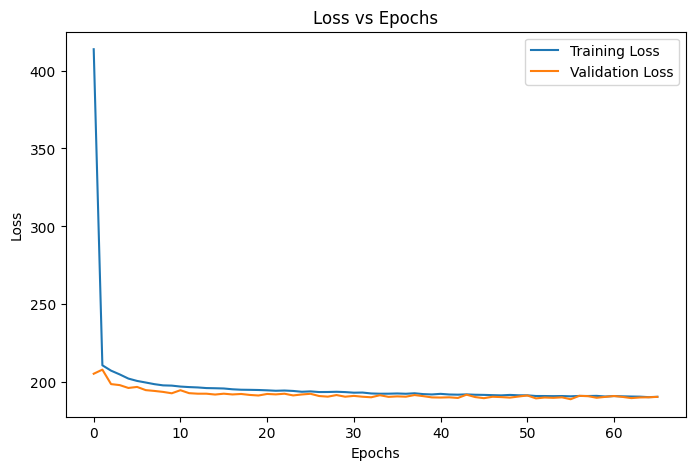

In [24]:
### Plot Loss vs Epochs
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')
plt.legend()
plt.show()


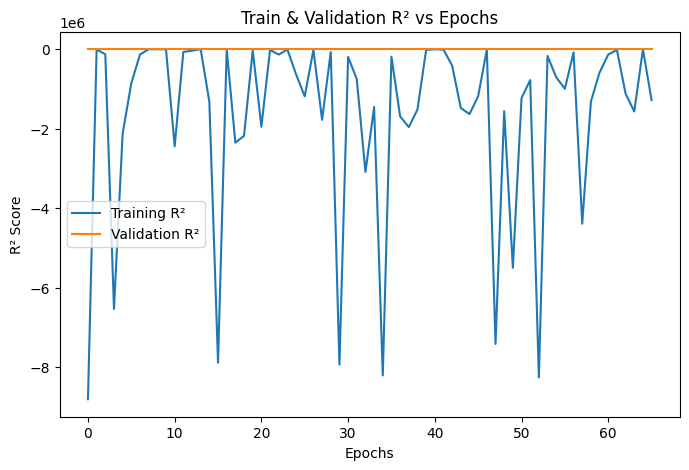

In [25]:
### Plot R² vs Epochs
plt.figure(figsize=(8, 5))
plt.plot(history.history['r2'], label='Training R²')
plt.plot(history.history['val_r2'], label='Validation R²')
plt.xlabel('Epochs')
plt.ylabel('R² Score')
plt.title('Train & Validation R² vs Epochs')
plt.legend()
plt.show()


In [26]:
et=datetime.now()

In [27]:
print(et)

2025-03-17 18:41:47.495839


#### 2025-03-17 14:20:56.614818

In [29]:
execution_duration=et-st

In [75]:
print(execution_duration)

3:17:55.399711
